<a href="https://colab.research.google.com/github/zaibshahzadi/DL-Internship/blob/main/Deep_Learning_CIFAR_10_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================
# Import Required Libraries
# ===============================

import os
import pickle
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)

TensorFlow Version: 2.20.0
NumPy Version: 2.0.2


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile

zip_path = "archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

print(os.listdir())

['.config', 'archive.zip', 'cifar-10-batches-py', 'sample_data']


In [ ]:
dataset_path = "cifar-10-batches-py"

print(os.listdir(dataset_path))

['data_batch_5', 'batches.meta', 'data_batch_2', 'test_batch', 'data_batch_1', 'readme.html', 'data_batch_4', 'data_batch_3']


In [ ]:
# ============================================
# Load CIFAR-10 Batch Files
# ============================================

import os
import pickle
import numpy as np

dataset_path = "cifar-10-batches-py"

# Function to load one batch
def load_batch(file_path):
    with open(file_path, "rb") as file:
        batch = pickle.load(file, encoding="bytes")
    return batch

# Load all training batches
train_batches = []

for i in range(1, 6):
    batch = load_batch(os.path.join(dataset_path, f"data_batch_{i}"))
    train_batches.append(batch)

# Load test batch
test_batch = load_batch(os.path.join(dataset_path, "test_batch"))

print("All batches loaded successfully!")

All batches loaded successfully!


In [ ]:
# ============================================
# Merge All Training Batches
# ============================================

X_train = np.concatenate([batch[b'data'] for batch in train_batches])
y_train = np.concatenate([batch[b'labels'] for batch in train_batches])

X_test = test_batch[b'data']
y_test = np.array(test_batch[b'labels'])

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (50000, 3072)
Training Labels : (50000,)
Testing Images : (10000, 3072)
Testing Labels : (10000,)


In [ ]:
# ============================================
# Load Class Names
# ============================================

meta = load_batch(os.path.join(dataset_path, "batches.meta"))

class_names = [label.decode("utf-8") for label in meta[b'label_names']]

print("Classes:")
print(class_names)

Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# ============================================
# Reshape Images
# ============================================

X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (50000, 32, 32, 3)
Testing Shape : (10000, 32, 32, 3)


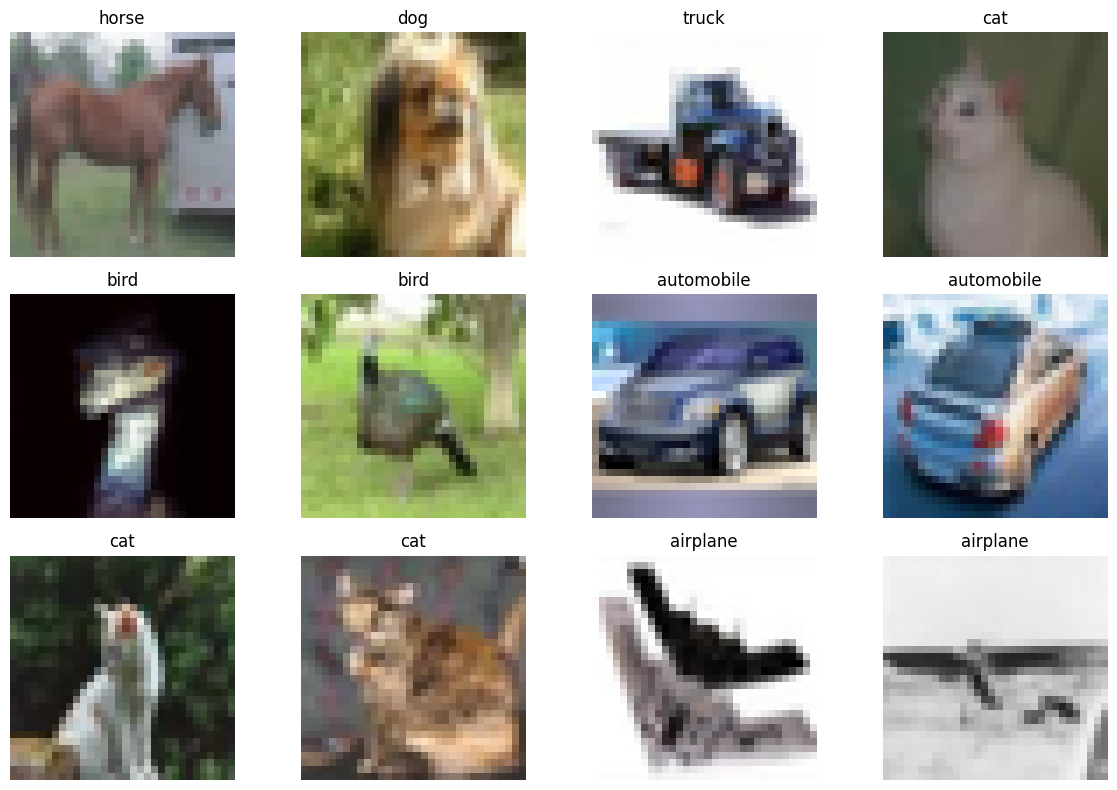

In [ ]:
# ============================================
# Display Sample Images
# ============================================

import matplotlib.pyplot as plt
import random

plt.figure(figsize=(12, 8))

for i in range(12):
    index = random.randint(0, len(X_train) - 1)

    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[index])
    plt.title(class_names[y_train[index]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Normalize Images
# ============================================

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


In [ ]:
# ============================================
# One-Hot Encoding
# ============================================

from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape :", y_test.shape)

Training Labels Shape : (50000, 10)
Testing Labels Shape : (10000, 10)


In [ ]:
# ============================================
# Train Validation Split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y_train, axis=1)
)

print("Training :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing :", X_test.shape)

Training : (40000, 32, 32, 3)
Validation : (10000, 32, 32, 3)
Testing : (10000, 32, 32, 3)


In [ ]:
# ============================================
# Data Augmentation
# ============================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    zoom_range=0.10
)

datagen.fit(X_train)

print("Data Augmentation Ready!")

Data Augmentation Ready!


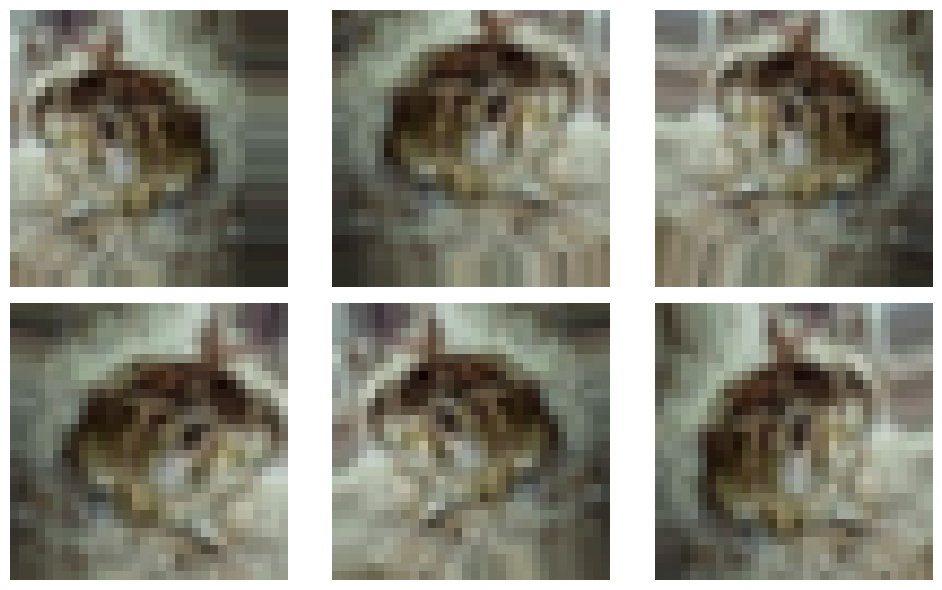

In [ ]:
# ============================================
# Show Augmented Images
# ============================================

import matplotlib.pyplot as plt

sample = X_train[0].reshape((1, 32, 32, 3))

plt.figure(figsize=(10, 6))

i = 0
for batch in datagen.flow(sample, batch_size=1):
    plt.subplot(2, 3, i + 1)
    plt.imshow(batch[0])
    plt.axis("off")
    i += 1
    if i == 6:
        break

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Build CNN Model
# ============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential()

# -------- Block 1 --------
model.add(Conv2D(32, (3,3), padding='same', activation='relu',
                 input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# -------- Block 2 --------
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.30))

# -------- Block 3 --------
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.40))

# Fully Connected Layer
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.50))

# Output Layer
model.add(Dense(10, activation='softmax'))

print("CNN Model Created Successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Created Successfully!


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438,058 (1.67 MB)

 Trainable params: 437,610 (1.67 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ============================================
# Compile Model
# ============================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [ ]:
# ============================================
# Train CNN
# ============================================

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=20,
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 223s 357ms/step - accuracy: 0.3101 - loss: 1.8588 - val_accuracy: 0.3674 - val_loss: 1.8887
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 233s 372ms/step - accuracy: 0.4114 - loss: 1.6022 - val_accuracy: 0.4470 - val_loss: 1.6387
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 230s 368ms/step - accuracy: 0.4728 - loss: 1.4457 - val_accuracy: 0.5384 - val_loss: 1.2942
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 215s 344ms/step - accuracy: 0.5213 - loss: 1.3358 - val_accuracy: 0.5546 - val_loss: 1.2513
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 216s 346ms/step - accuracy: 0.5616 - loss: 1.2370 - val_accuracy: 0.6221 - val_loss: 1.0984
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 216s 346ms/step - accuracy: 0.5877 - loss: 1.1668 - val_accuracy: 0.5937 - val_loss: 1.1837
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 226s 361ms/step - accuracy: 0.6107 - loss: 1.1175 - val_accuracy: 0.6768 - val_loss: 0.9488
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 215s 344ms/step - accuracy: 0.6258 -

In [ ]:
# ============================================
# Evaluate Model
# ============================================

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 88ms/step - accuracy: 0.7730 - loss: 0.6642

Test Loss: 0.6642
Test Accuracy: 0.7730


In [ ]:
# ============================================
# Save Model
# ============================================

model.save("cnn_cifar10_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


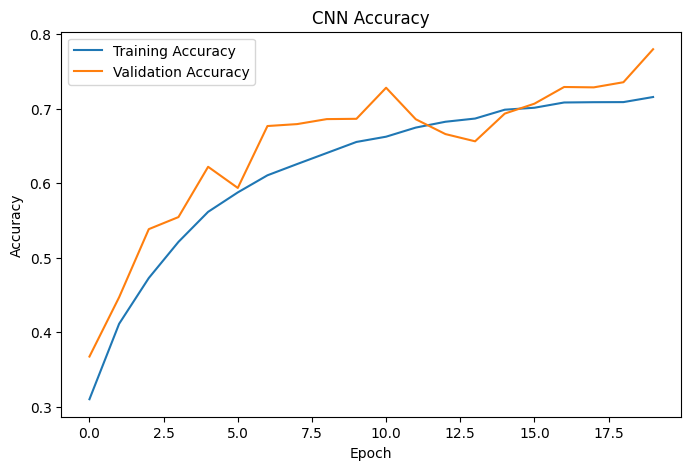

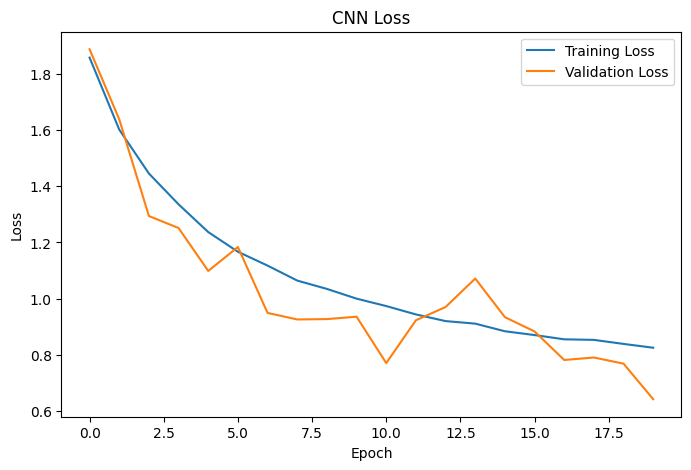

In [ ]:
# ============================================
# Accuracy and Loss Curves
# ============================================

import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step


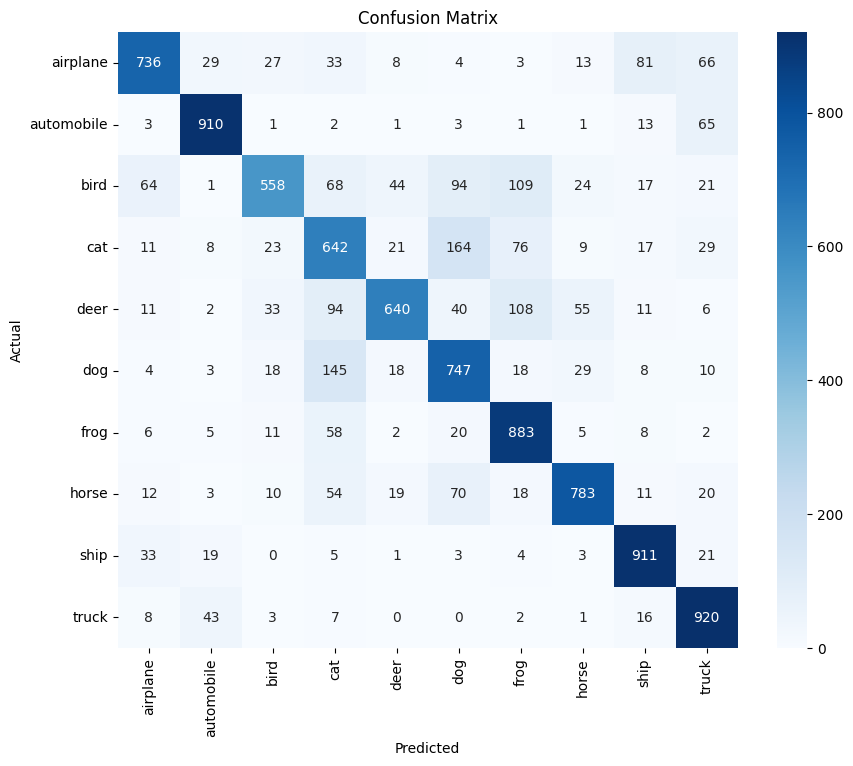

In [ ]:
# ============================================
# Confusion Matrix
# ============================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# ============================================
# Classification Report
# ============================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.83      0.74      0.78      1000
  automobile       0.89      0.91      0.90      1000
        bird       0.82      0.56      0.66      1000
         cat       0.58      0.64      0.61      1000
        deer       0.85      0.64      0.73      1000
         dog       0.65      0.75      0.70      1000
        frog       0.72      0.88      0.79      1000
       horse       0.85      0.78      0.81      1000
        ship       0.83      0.91      0.87      1000
       truck       0.79      0.92      0.85      1000

    accuracy                           0.77     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.78      0.77      0.77     10000



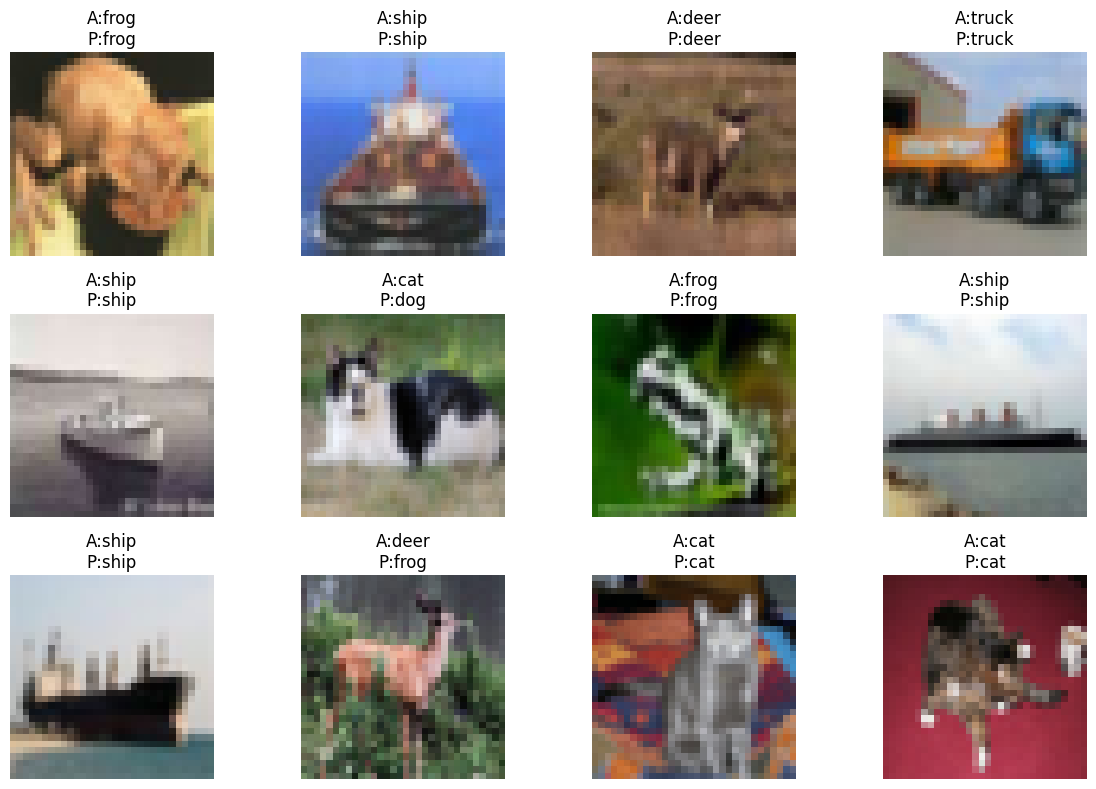

In [ ]:
# ============================================
# Show Predictions
# ============================================

import random

plt.figure(figsize=(12,8))

for i in range(12):

    index = random.randint(0, len(X_test)-1)

    plt.subplot(3,4,i+1)

    plt.imshow(X_test[index])

    actual = class_names[np.argmax(y_test[index])]
    predicted = class_names[y_pred_classes[index]]

    plt.title(f"A:{actual}\nP:{predicted}")

    plt.axis("off")

plt.tight_layout()
plt.show()